In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df_types = pd.read_csv("transaction_types.csv")
df_txn = pd.read_csv("transactions_data_training.csv")
df_profile = pd.read_csv("user_profile.csv")
df_mcc = pd.read_csv("mcc_group_definition.csv")

In [3]:
df_txn.head()

,user_id,transaction_date,transaction_type,mcc_group,amount_n26_currency,dataset_transaction,dataset_user
0,a78884f5e76951188c1e719d4956773a,2016-02-01,DT,NaN,350,training,training
1,b0333294fef6ff1299102a70ad46b126,2016-02-01,DT,NaN,202,training,training
2,7b8d2a2780adae0cd0c248e92c1b28dc,2016-02-01,DT,NaN,291,training,training
3,cc4abaa500f7db4390ae3f02bd36d805,2016-02-01,DT,NaN,214,training,training
4,49b99d1d5ba028566639e8b3eb7c055b,2016-02-01,DT,NaN,272,training,training


In [4]:
df_mcc.head()

,mcc_group,explanation
0,1,ATM
1,2,Groceries
2,3,Gastronomie
3,4,Shopping/(Fashion)
4,5,"Home and DIY, House Energy"


In [5]:
df_profile.head()

,user_id,age,age_band,country,city_tier,employment_status,industry,income_band,account_tenure_days
0,000295594379774ab9ac2c78c946d615,47,45-54,DE,2,self_employed,healthcare,50-75k,119
1,000aa792d73dd82b16a29692772d395a,61,55+,AT,1,employed_ft,finance,50-75k,134
2,0011103fe4ba1264342882b7ab98c641,58,55+,FR,1,retired,other,50-75k,109
3,001679c77c33d7efabf800596fb2a978,53,45-54,DE,2,self_employed,education,50-75k,127
4,001e72a2f4c4376f10011735dde39cd5,28,25-34,IE,2,employed_ft,healthcare,30-50k,94


In [6]:
df_types.head()

,type,explanation,direction,agent
0,AR,Authorization reject,-,Card
1,AE,Authorization expired,In,Card
2,AV,Authorization Reversal,In,Card
3,BBU,Cash26 deposit,In,Partner
4,CT,Credit Transfer,In,Bank Account


In [7]:
df_txn.dtypes

user_id                    str
transaction_date           str
transaction_type           str
mcc_group              float64
amount_n26_currency      int64
dataset_transaction        str
dataset_user               str
dtype: object

In [8]:
df_txn["transaction_date"] = pd.to_datetime(df_txn["transaction_date"])

In [9]:
df_txn.dtypes

user_id                           str
transaction_date       datetime64[us]
transaction_type                  str
mcc_group                     float64
amount_n26_currency             int64
dataset_transaction               str
dataset_user                      str
dtype: object

In [10]:
print(f"Total transaction :" ,df_txn.shape[0], 
      f", User :", df_txn["user_id"].nunique())

Total transaction : 408546 , User : 10000


In [11]:
df_profile.shape

(9470, 9)

In [12]:
direction_map = (
    df_types.set_index("type")["direction"].to_dict()
)

In [13]:
direction_map

{'AR': '-',
 'AE': 'In',
 'AV': 'In',
 'BBU': 'In',
 'CT': 'In',
 'DI': 'In',
 'DR': 'In',
 'PF': 'In',
 'PR': 'In',
 'WU': 'In',
 'AA': 'Out',
 'BUB': 'Out',
 'DD': 'Out',
 'DT': 'Out',
 'FT': 'Out',
 'PT': 'Out',
 'TUB': 'Out',
 'TBU': 'In',
 'WEE': 'Out',
 'AL': 'In',
 'AU': 'Out',
 'BUS': 'Out',
 'BRU': 'Out'}

In [14]:
df_txn["direction"] = df_txn["transaction_type"].map(direction_map)

In [15]:
df_txn.head()

,user_id,transaction_date,transaction_type,mcc_group,amount_n26_currency,dataset_transaction,dataset_user,direction
0,a78884f5e76951188c1e719d4956773a,2016-02-01,DT,NaN,350,training,training,Out
1,b0333294fef6ff1299102a70ad46b126,2016-02-01,DT,NaN,202,training,training,Out
2,7b8d2a2780adae0cd0c248e92c1b28dc,2016-02-01,DT,NaN,291,training,training,Out
3,cc4abaa500f7db4390ae3f02bd36d805,2016-02-01,DT,NaN,214,training,training,Out
4,49b99d1d5ba028566639e8b3eb7c055b,2016-02-01,DT,NaN,272,training,training,Out


In [16]:
df_txn["direction"].isna().sum()

np.int64(0)

In [17]:
df_txn['direction'].value_counts()

direction
Out    336421
In      72125
Name: count, dtype: int64

In [18]:
assert (df_txn['amount_n26_currency'] > 0).all()

In [19]:
df_txn["mcc_group"].isna().sum()

np.int64(150222)

In [20]:
df_profile.columns

Index(['user_id', 'age', 'age_band', 'country', 'city_tier',
       'employment_status', 'industry', 'income_band', 'account_tenure_days'],
      dtype='str')

In [21]:
df_profile_clean = df_profile.drop(
    columns = ["age", "account_tenure_days"]
)

In [22]:
df_profile_clean.head()

,user_id,age_band,country,city_tier,employment_status,industry,income_band
0,000295594379774ab9ac2c78c946d615,45-54,DE,2,self_employed,healthcare,50-75k
1,000aa792d73dd82b16a29692772d395a,55+,AT,1,employed_ft,finance,50-75k
2,0011103fe4ba1264342882b7ab98c641,55+,FR,1,retired,other,50-75k
3,001679c77c33d7efabf800596fb2a978,45-54,DE,2,self_employed,education,50-75k
4,001e72a2f4c4376f10011735dde39cd5,25-34,IE,2,employed_ft,healthcare,30-50k


In [23]:
df_txn['transaction_date'].min(), df_txn['transaction_date'].max()


(Timestamp('2016-02-01 00:00:00'), Timestamp('2016-07-31 00:00:00'))

In [24]:
train_start = "2016-02-01"
train_end ="2016-05-31"
target_start = "2016-06-01"
target_end = "2016-07-31"

In [25]:
df_train_txn = df_txn[(df_txn["transaction_date"] >= train_start) & (df_txn["transaction_date"] <= train_end)]
df_target_txn = df_txn[(df_txn["transaction_date"] >= target_start) & (df_txn["transaction_date"] <= target_end)]


In [26]:
print(
    f"Feature window: {len(df_train_txn):,} txns "
    f"({train_start} to {train_end})"
)
print(
    f"Target window:  {len(df_target_txn):,} txns "
    f"({target_start} to {target_end})"
)

Feature window: 267,593 txns (2016-02-01 to 2016-05-31)
Target window:  140,953 txns (2016-06-01 to 2016-07-31)


In [27]:
df_train_txn.head()

,user_id,transaction_date,transaction_type,mcc_group,amount_n26_currency,dataset_transaction,dataset_user,direction
0,a78884f5e76951188c1e719d4956773a,2016-02-01,DT,NaN,350,training,training,Out
1,b0333294fef6ff1299102a70ad46b126,2016-02-01,DT,NaN,202,training,training,Out
2,7b8d2a2780adae0cd0c248e92c1b28dc,2016-02-01,DT,NaN,291,training,training,Out
3,cc4abaa500f7db4390ae3f02bd36d805,2016-02-01,DT,NaN,214,training,training,Out
4,49b99d1d5ba028566639e8b3eb7c055b,2016-02-01,DT,NaN,272,training,training,Out


In [28]:
model_users = sorted(
    df_train_txn["user_id"].unique()
)

In [29]:
model_users

['000295594379774ab9ac2c78c946d615',
 '000aa792d73dd82b16a29692772d395a',
 '0011103fe4ba1264342882b7ab98c641',
 '001679c77c33d7efabf800596fb2a978',
 '001e72a2f4c4376f10011735dde39cd5',
 '001f9baedaf3c8487c344d25b0eda9fc',
 '002244240e165748694a06f8cce13e6d',
 '002ac9e8fe1c2f40d117065851ac7277',
 '0031c63ceff3257d599606f8665268d6',
 '0035239d52fb8a82d84422420302f26a',
 '003b0bcbafbaf5971027f95d1d084e77',
 '003ef334dd92e9a9be337df65eeb87b1',
 '0046f394f7e57d2387021c1dbbe0ac0b',
 '0048233ffb64776094f7b3d390ff1d76',
 '004c53000927f6dd662203e8d0945ce8',
 '0055be8b144cff505d99fdec39d6c27a',
 '0061d7639ec45847f10ca06098c40197',
 '00699999ffef13d0f2c48ef109169164',
 '008060002c5f4b7f3b78a8979991b652',
 '0082dace2f94dbb8a336cd15554005f6',
 '008b2aef567fb98a07632c3f3361c52f',
 '009d87661e269f4ed5d97d8eaba07c70',
 '009f41108caa00c8b9f1da8a7ab43a20',
 '00a016dbd4644314d7ea7d609cc234d8',
 '00aaabcbbec72479023949db07c22717',
 '00b17c6aaf21350c36d9488e1fade4e6',
 '00ba9fdb3aa7b679530594757efbe3e2',
 

In [30]:
target_in = (
    df_target_txn[df_target_txn["direction"] == "In"].groupby("user_id")["amount_n26_currency"].sum()
)

target_out = (
    df_target_txn[df_target_txn["direction"] == "Out"].groupby("user_id")["amount_n26_currency"].sum()
)

In [31]:
target_in.head()

user_id
000295594379774ab9ac2c78c946d615     115
000aa792d73dd82b16a29692772d395a     155
0011103fe4ba1264342882b7ab98c641    1578
001679c77c33d7efabf800596fb2a978    2280
001f9baedaf3c8487c344d25b0eda9fc      52
Name: amount_n26_currency, dtype: int64

In [32]:
targets = pd.DataFrame(index = model_users)
targets.index.name = "user_id"
targets['total_income'] = (
    target_in.reindex(model_users).fillna(0)
)

targets['total_expenses'] = (
    target_out.reindex(model_users).fillna(0)
)

n_churn = (
    (targets['total_income'] == 0)
    & (targets['total_expenses'] == 0)
).sum()

print(
    f"Population: {len(model_users):,} users "
    f"({n_churn:,} churned = target 0)"
)
print(targets.describe().to_string())


Population: 9,470 users (1,642 churned = target 0)


       total_income  total_expenses
count   9470.000000     9470.000000
mean     352.091658      425.058289
std      570.404906      778.001201
min        0.000000        0.000000
25%        0.000000       13.000000
50%      112.000000      136.000000
75%      465.000000      521.000000
max     7820.000000    14603.000000


In [33]:
targets

,total_income,total_expenses
user_id,,
000295594379774ab9ac2c78c946d615,115.0,77.0
000aa792d73dd82b16a29692772d395a,155.0,228.0
0011103fe4ba1264342882b7ab98c641,1578.0,1103.0
001679c77c33d7efabf800596fb2a978,2280.0,2817.0
001e72a2f4c4376f10011735dde39cd5,0.0,0.0
...,...,...
fff571276eaa49853039f6bfe1102fba,55.0,32.0
fff6ea4b3659a969c62c17c1d1655394,0.0,22.0
fff9eec15875baad3df433c8780aa3bd,23.0,167.0


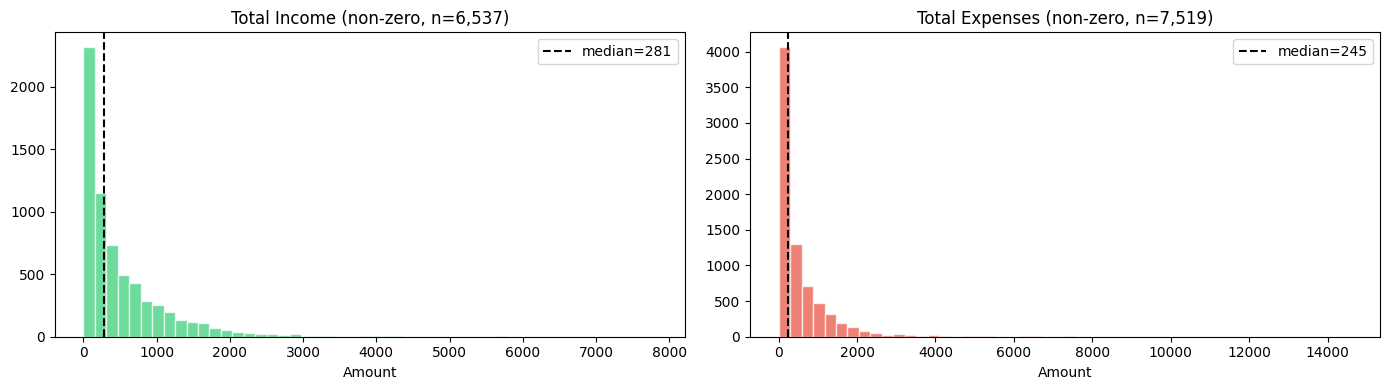

In [35]:
fig_targets, _axs_tgt = plt.subplots(
    1, 2, figsize=(14, 4),
)

for _i, (_col, _color) in enumerate([
    ('total_income', '#2ecc71'),
    ('total_expenses', '#e74c3c'),
]):
    _ax = _axs_tgt[_i]
    _vals = targets[_col]
    _nz = _vals[_vals > 0]
    _ax.hist(
        _nz, bins=50, color=_color, alpha=0.7,
        edgecolor='white',
    )
    _ax.set_title(
        f'{_col.replace("_", " ").title()} '
        f'(non-zero, n={len(_nz):,})'
    )
    _ax.set_xlabel('Amount')
    _ax.axvline(
        _nz.median(), color='black',
        ls='--', label=f'median={_nz.median():.0f}',
    )
    _ax.legend()
plt.tight_layout()
plt.show()